# Analysis (20250220)

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [3]:
data, platemap = pr.load_platereader_data(
    data_file="../02-data/20250220-MTHFS-02.txt", 
    platemap_file="../01-design/platemap.tsv", 
    platereader="biotek"
)
data

,Well,Row,Column,Time,Seconds,Temperature (C),Read,Data,Sample #,Name,...,SMS-03-06,bnext p-mix-03-03,NEB Solution A,NEB solution B,RNAse Inhibitor,DNA (deGFP),H2O,MTHFS,"0.2 mM 5,10-methenyl-THF",Total Volume
0,D2,D,2,0 days 00:00:00,0.00,37.00,"485/20,528/20",0.00,1,no folinic acid,...,4.00,1.30,NaN,NaN,0.40,0.50,1.00,0.00,NaN,10.00
1,D2,D,2,0 days 00:05:00,300.00,37.00,"485/20,528/20",7.00,1,no folinic acid,...,4.00,1.30,NaN,NaN,0.40,0.50,1.00,0.00,NaN,10.00
2,D2,D,2,0 days 00:10:00,600.00,37.00,"485/20,528/20",17.00,1,no folinic acid,...,4.00,1.30,NaN,NaN,0.40,0.50,1.00,0.00,NaN,10.00
3,D2,D,2,0 days 00:15:00,900.00,37.00,"485/20,528/20",30.00,1,no folinic acid,...,4.00,1.30,NaN,NaN,0.40,0.50,1.00,0.00,NaN,10.00
4,D2,D,2,0 days 00:20:00,1200.00,37.00,"485/20,528/20",40.00,1,no folinic acid,...,4.00,1.30,NaN,NaN,0.40,0.50,1.00,0.00,NaN,10.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,D20,D,20,0 days 08:40:00,31200.00,37.00,"485/20,528/20",5.00,10,Negative,...,NaN,NaN,4.00,3.00,0.00,0.00,3.00,NaN,NaN,10.00
1086,D20,D,20,0 days 08:45:00,31500.00,37.00,"485/20,528/20",5.00,10,Negative,...,NaN,NaN,4.00,3.00,0.00,0.00,3.00,NaN,NaN,10.00
1087,D20,D,20,0 days 08:50:00,31800.00,37.00,"485/20,528/20",6.00,10,Negative,...,NaN,NaN,4.00,3.00,0.00,0.00,3.00,NaN,NaN,10.00
1088,D20,D,20,0 days 08:55:00,32100.00,37.00,"485/20,528/20",6.00,10,Negative,...,NaN,NaN,4.00,3.00,0.00,0.00,3.00,NaN,NaN,10.00


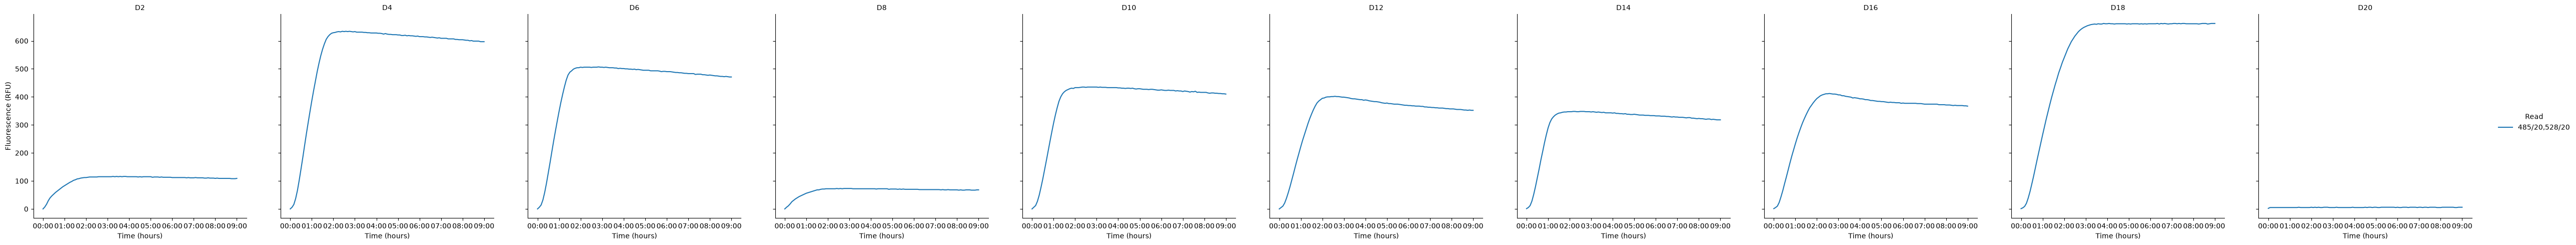

In [4]:
pr.plot_plate(data)

In [5]:
names_to_remove = ['5,10-methenyl-THF', 
                   'folinic + BE MTHFS (1 uL)', 
                   'folinic + BE MTHFS (1.61 uL)',
                   'NEB ribosome control']

replace_dict = {'no folinic acid':'no Folinic Acid',
                'no folinic + 5,10-methenyl-THF':'5,10-methenyl-THF',
                'folinic':'Folinic Acid',
                'folinic + MTHFS (0.5 uL)':'Folinic Acid + MTHFS'}

custom_order = ['no Folinic Acid', 
                'Folinic Acid', 
                'Folinic Acid + MTHFS', 
                '5,10-methenyl-THF', 
                'Positive', 
                'Negative']

data_drop = data.drop(data[data['Name'].isin(names_to_remove)].index)
data_drop['Name'] = data_drop['Name'].replace(replace_dict)

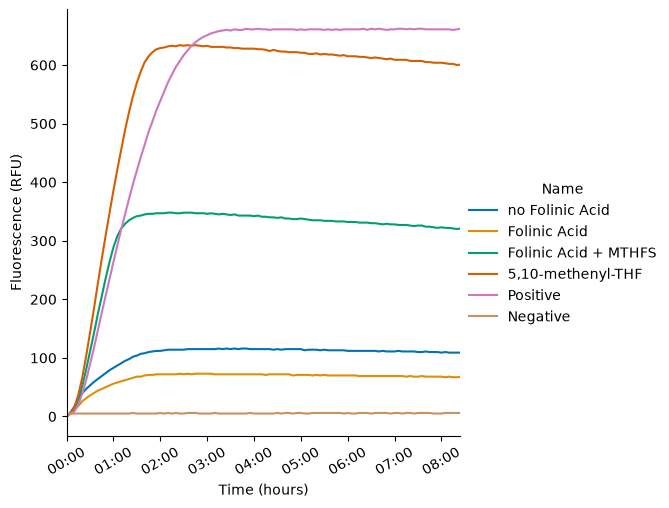

In [6]:
#| label: fig:kinetics

# Generate the plot (assuming `pr.plot_curves` returns a FacetGrid object)
sns.set_palette('colorblind')
g = pr.plot_curves(data_drop, hue_order=custom_order)
g.set_xticklabels(rotation=30)
plt.xlim([0,0.35])

plt.savefig("MTHFS_kinetics.png");

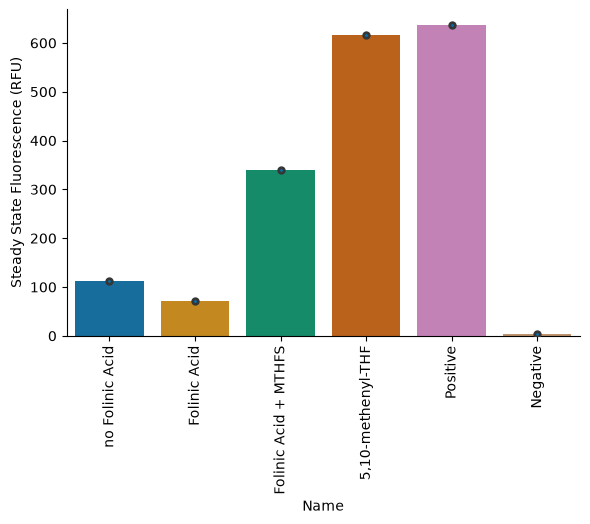

In [7]:
#| label: fig:endpoint

pr.plot_steadystate(data_drop, order=custom_order, palette='colorblind')

plt.savefig("MTHFS_endpoint.png");

In [8]:
kinetics = pr.kinetic_analysis(data_drop)

In [9]:
kinetics = pr.kinetic_analysis(data_drop)
# pr.plot_kinetics(data_drop, kinetics=kinetics) crashes inside nucleus-cdk itself (ax.axvline compares a Timedelta to a float) regardless of args passed here - not fixable from the notebook. Filed as https://github.com/bnext-bio/bnext/issues/66. Doesn't generate a figure used in this devnote, so commenting out rather than blocking on the upstream fix.

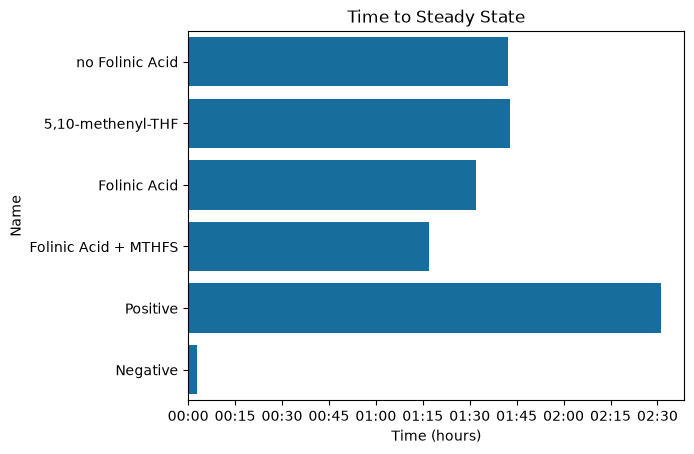

In [10]:
ax = sns.barplot(data=kinetics["Steady State"], y="Name", x="Time", orient="y")
ax.set_title("Time to Steady State")
pr._plot_timedelta(ax)


Text(0.5, 0, '$V_{max}$ (u/s)')

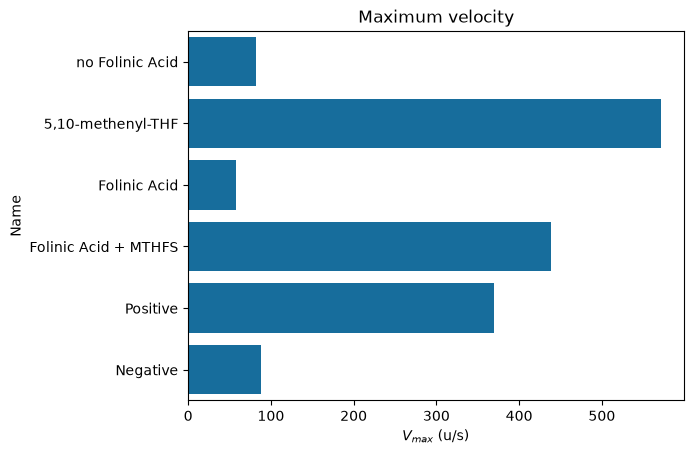

In [11]:
ax = sns.barplot(data=kinetics["Velocity"], y="Name", x="Max", orient="y")
ax.set_title("Maximum velocity")
ax.set_xlabel("$V_{max}$ (u/s)")